# DeepHybrid Benchmark Evaluation

Evaluate trained DeepACO JSSP models across the full JobShopLib benchmark catalog,
choose benchmark families or exact instances, load weights from `.pt` or Lightning `.ckpt`,
and plot comparison charts.


In [9]:
# Optional Colab bootstrap
import os
from pathlib import Path

try:
    import google.colab  # type: ignore
    IN_COLAB = True
except Exception:
    IN_COLAB = False

if IN_COLAB and not Path('/content/DeepHybrid').exists():
    !git clone https://github.com/pranceraz/DeepHybrid.git

if IN_COLAB:
    os.chdir('/content/DeepHybrid')

# Core deps for this notebook
!pip -q install rl4co[graph] torch-geometric job-shop-lib pandas matplotlib

print('Working dir:', os.getcwd())


Working dir: /content/DeepHybrid


In [10]:
import glob
import pickle
import re
from collections import defaultdict
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import torch
from tensordict.tensordict import TensorDict

from job_shop_lib.benchmarking import load_all_benchmark_instances, load_benchmark_instance

from generator import MyJSSPGenerator
from my_env import OperationSelectionEnv
from init_embedding import JSSPInitEmbedding, JsspEdgeEmbedding
from aco_class import MyAntSystem
from rl4co.models.zoo.nargnn.encoder import NARGNNEncoder
from rl4co.models.zoo.deepaco.policy import DeepACOPolicy
from rl4co.models.zoo.deepaco.model import DeepACO

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print('DEVICE:', DEVICE)


DEVICE: cpu


In [11]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [45]:
# ===============================
# User Config
# ===============================

# Type model paths directly here. Add more than one if you want comparisons.
MODEL_PATHS = [
    '/content/drive/MyDrive/DeepHybrid/training_runs/small_small_deepaco_jssp_10x10_20260422_040133/checkpoints/deepaco-epoch=59-step=015360.ckpt',
    '/content/drive/MyDrive/DeepHybrid/training_runs/bigbigdeepaco_jssp_10x10_20260422_035859/checkpoints/deepaco-epoch=53-step=013824.ckpt',
    # '/content/drive/MyDrive/DeepHybrid/training_runs/.../checkpoints/last.ckpt',
]

# Type benchmark keywords or exact benchmark names here.
# Examples: ['ft06'], ['ft'], ['ta'], ['ft06', 'ta01']
BENCHMARK_KEYWORDS = [
    #'abz5',#'orb01','orb02','orb03','orb04','orb05','orb06','orb07',#'orb08','orb09','orb10',
    'la16','la17','la18',#'la19','la20','ft10','abz5','abz6',
]


# If True, fallback to full trusted checkpoint loading for your own .ckpt files.
TRUST_CHECKPOINTS = True

MODEL_GLOB_PATTERNS = [
    '*.pt',
    'lightning_logs/version_*/checkpoints/*.ckpt',
    'training_runs/*/*.pt',
    'training_runs/*/checkpoints/*.ckpt',
    '/content/drive/MyDrive/DeepHybrid/training_runs/*/*.pt',
    '/content/drive/MyDrive/DeepHybrid/training_runs/*/checkpoints/*.ckpt',
]

# Inference controls
N_ANTS_TEST = 64
N_ITER_TEST = 10
RUN_CLASSIC_ACO = False
CLASSIC_ACO_N_ANTS = 64
CLASSIC_ACO_N_ITERATIONS = 10

def natural_sort_key(text: str):
    return [int(part) if part.isdigit() else part.lower() for part in re.split(r'(\d+)', text)]


def benchmark_family(name: str) -> str:
    match = re.match(r'[A-Za-z]+', name)
    return match.group(0).lower() if match else name.lower()


ALL_BENCHMARKS = load_all_benchmark_instances()
ALL_BENCHMARK_NAMES = sorted(ALL_BENCHMARKS.keys(), key=natural_sort_key)

BENCHMARKS_BY_GROUP = defaultdict(list)
for benchmark_name in ALL_BENCHMARK_NAMES:
    BENCHMARKS_BY_GROUP[benchmark_family(benchmark_name)].append(benchmark_name)

AVAILABLE_GROUPS = sorted(BENCHMARKS_BY_GROUP.keys(), key=natural_sort_key)


def discover_model_paths():
    paths = []
    for pattern in MODEL_GLOB_PATTERNS:
        paths.extend(glob.glob(pattern))
    return sorted({str(Path(p)) for p in paths}, key=natural_sort_key)


DISCOVERED_MODEL_PATHS = discover_model_paths()


def resolve_model_paths(model_paths):
    cleaned = [str(Path(p)) for p in model_paths if str(p).strip()]
    if cleaned:
        return cleaned
    if DISCOVERED_MODEL_PATHS:
        return DISCOVERED_MODEL_PATHS
    raise RuntimeError('No model artifacts found. Set MODEL_PATHS to a .pt or .ckpt path.')


def resolve_benchmark_names(keywords):
    resolved = []
    for keyword in keywords:
        kw = keyword.strip().lower()
        if not kw:
            continue
        if kw == 'all':
            resolved.extend(ALL_BENCHMARK_NAMES)
            continue
        if kw in BENCHMARKS_BY_GROUP:
            resolved.extend(BENCHMARKS_BY_GROUP[kw])
            continue
        matches = [name for name in ALL_BENCHMARK_NAMES if name.lower().startswith(kw)]
        if matches:
            resolved.extend(matches)
            continue
        raise RuntimeError(f'No benchmark matched keyword: {keyword}')
    if not resolved:
        raise RuntimeError('No benchmarks selected. Set BENCHMARK_KEYWORDS to values like ft06, ft, ta, or all.')
    return sorted(set(resolved), key=natural_sort_key)


print('Available benchmark groups:', ', '.join(['all'] + AVAILABLE_GROUPS))
print('Total benchmarks in job_shop_lib:', len(ALL_BENCHMARK_NAMES))
print('Auto-discovered model artifacts:')
for p in DISCOVERED_MODEL_PATHS:
    print(' -', p)


Available benchmark groups: all, abz, ft, la, orb, swv, ta, yn
Total benchmarks in job_shop_lib: 162
Auto-discovered model artifacts:
 - /content/drive/MyDrive/DeepHybrid/training_runs/3x3_deepaco_jssp_3x3_20260422_102808/3x3_deepaco_jssp_3x3_20260422_102808.pt
 - /content/drive/MyDrive/DeepHybrid/training_runs/3x3_deepaco_jssp_3x3_20260422_102808/checkpoints/deepaco-epoch=00-step=000128.ckpt
 - /content/drive/MyDrive/DeepHybrid/training_runs/3x3_deepaco_jssp_3x3_20260422_102808/checkpoints/deepaco-epoch=01-step=000256.ckpt
 - /content/drive/MyDrive/DeepHybrid/training_runs/3x3_deepaco_jssp_3x3_20260422_102808/checkpoints/deepaco-epoch=02-step=000384.ckpt
 - /content/drive/MyDrive/DeepHybrid/training_runs/3x3_deepaco_jssp_3x3_20260422_102808/checkpoints/deepaco-epoch=03-step=000512.ckpt
 - /content/drive/MyDrive/DeepHybrid/training_runs/3x3_deepaco_jssp_3x3_20260422_102808/checkpoints/deepaco-epoch=04-step=000640.ckpt
 - /content/drive/MyDrive/DeepHybrid/training_runs/3x3_deepaco_jssp_

In [46]:
# ===============================
# Helpers: model loading + conversion
# ===============================

class FixedBatchGenerator:
    """Compatibility stub so notebook-saved Lightning checkpoints can unpickle."""
    def __init__(self, base_generator=None, batch_size=None):
        self.base = base_generator
        self.batch_size = batch_size


SAFE_GLOBALS = [
    OperationSelectionEnv,
    MyJSSPGenerator,
    FixedBatchGenerator,
    JSSPInitEmbedding,
    JsspEdgeEmbedding,
    MyAntSystem,
]


def load_state_dict_from_artifact(path: str) -> dict:
    try:
        with torch.serialization.safe_globals(SAFE_GLOBALS):
            obj = torch.load(path, map_location='cpu', weights_only=True)
    except Exception as weights_error:
        if not TRUST_CHECKPOINTS:
            raise RuntimeError(
                f'weights_only load failed for {path}. Set TRUST_CHECKPOINTS=True if this is your own checkpoint.'
            ) from weights_error
        try:
            obj = torch.load(path, map_location='cpu', weights_only=False)
        except Exception as full_error:
            raise RuntimeError(
                f'Failed to load checkpoint {path} with both weights_only=True and weights_only=False.'
            ) from full_error
    if isinstance(obj, dict) and 'state_dict' in obj:
        return obj['state_dict']
    if isinstance(obj, dict):
        return obj
    raise ValueError(f'Unsupported artifact format: {path}')


def infer_embed_dim_from_state_dict(sd: dict) -> int:
    # scalar_embed.weight shape: [embed_dim, num_feats]
    key = 'policy.encoder.init_embedding.scalar_embed.weight'
    if key not in sd:
        raise KeyError(f'Missing key in state dict: {key}')
    return int(sd[key].shape[0])


def op_machine_from_jobshoplib_operation(op):
    # job_shop_lib Operation exposes either machine_id or machines
    if hasattr(op, 'machine_id') and op.machine_id is not None and int(op.machine_id) >= 0:
        return int(op.machine_id)

    machines = getattr(op, 'machines', None)
    if isinstance(machines, (list, tuple)):
        if len(machines) != 1:
            raise ValueError('Flexible operation encountered (multiple machines). This env expects classic JSSP.')
        return int(machines[0])

    return int(machines)


def instance_to_tensordict(instance) -> TensorDict:
    num_jobs = int(instance.num_jobs)
    num_machines = int(instance.num_machines)

    job_lengths = [len(job) for job in instance.jobs]
    total_ops = sum(job_lengths)

    start = []
    end = []
    cursor = 0
    for jl in job_lengths:
        start.append(cursor)
        end.append(cursor + jl - 1)
        cursor += jl

    proc_times = torch.zeros((1, num_machines, total_ops), dtype=torch.float32)
    machine_id = torch.empty((1, total_ops), dtype=torch.long)
    pos_in_job = torch.empty((1, total_ops), dtype=torch.float32)

    op_idx = 0
    for job in instance.jobs:
        for pos, op in enumerate(job):
            m = op_machine_from_jobshoplib_operation(op)
            d = int(op.duration)
            proc_times[0, m, op_idx] = float(d)
            machine_id[0, op_idx] = m
            pos_in_job[0, op_idx] = float(pos)
            op_idx += 1

    td = TensorDict(
        {
            'start_op_per_job': torch.tensor([start], dtype=torch.long),
            'end_op_per_job': torch.tensor([end], dtype=torch.long),
            'proc_times': proc_times,
            'pad_mask': torch.zeros((1, total_ops), dtype=torch.bool),
            'pos_in_job': pos_in_job,
            'machine_id': machine_id,
        },
        batch_size=[1],
    )

    return td


class SingleInstanceGenerator:
    def __init__(self, instance_td: TensorDict):
        self.instance_td = instance_td
        self.num_jobs = int(instance_td['start_op_per_job'].shape[-1])
        self.num_mas = int(instance_td['proc_times'].shape[1])
        self.n_ops_max = int(instance_td['proc_times'].shape[2])

    def __call__(self, batch_size=None):
        if batch_size is None:
            return self.instance_td.clone()
        if isinstance(batch_size, int):
            batch_size = [batch_size]
        b = int(batch_size[0])
        if b != 1:
            raise ValueError('SingleInstanceGenerator only supports batch_size=1 for benchmark eval.')
        return self.instance_td.clone()


def build_model_for_instance(instance, state_dict: dict):
    embed_dim = infer_embed_dim_from_state_dict(state_dict)
    num_machines = int(instance.num_machines)

    td_instance = instance_to_tensordict(instance)
    env = OperationSelectionEnv(SingleInstanceGenerator(td_instance))

    init_emb = JSSPInitEmbedding(embed_dim=embed_dim, num_machines=num_machines)
    edge_emb = JsspEdgeEmbedding(embed_dim=embed_dim)
    encoder = NARGNNEncoder(embed_dim=embed_dim, init_embedding=init_emb, edge_embedding=edge_emb)

    policy = DeepACOPolicy(
        encoder=encoder,
        env_name='tsp',
        n_ants=dict(train=10, val=20, test=N_ANTS_TEST),
        n_iterations=dict(train=1, val=5, test=N_ITER_TEST),
        aco_class=MyAntSystem,
    )

    model = DeepACO(
        env=env,
        policy=policy,
        train_with_local_search=False,
    )

    model.load_state_dict(state_dict, strict=True)
    model.to(DEVICE)
    model.eval()
    return model, env


In [47]:
# ===============================
# Helpers: rollout + metrics
# ===============================

@torch.no_grad()
def evaluate_model_makespan(model, env) -> float:
    td = env.reset(batch_size=[1])
    td = td.to(DEVICE)
    out = model.policy(td, env, phase='test')
    reward = out['reward']
    if reward.numel() > 1:
        reward = reward.mean()
    return float((-reward).item())


def rollout_baseline_makespan(env, strategy='first_valid', seed=0) -> float:
    g = torch.Generator(device='cpu')
    g.manual_seed(seed)

    td = env.reset(batch_size=[1])
    max_steps = int(env.num_ops * 3)

    for _ in range(max_steps):
        if env._get_done(td).all():
            break

        mask = td['action_mask'][0]
        valid = torch.where(mask)[0]
        if valid.numel() == 0:
            break

        if strategy == 'first_valid':
            a = valid[0]
        elif strategy == 'random':
            idx = torch.randint(0, valid.numel(), (1,), generator=g).item()
            a = valid[idx]
        else:
            raise ValueError(f'Unknown strategy: {strategy}')

        td['action'] = a.unsqueeze(0).to(td.device)
        td = env.step(td)['next']

    makespan = td['machine_available'].max().item()
    return float(makespan)


@torch.no_grad()
def evaluate_classic_aco_makespan(env, n_ants=CLASSIC_ACO_N_ANTS, n_iterations=CLASSIC_ACO_N_ITERATIONS) -> float:
    td = env.reset(batch_size=[1]).to(DEVICE)
    num_ops = env.num_ops
    log_heuristic = torch.zeros((1, num_ops, num_ops), device=DEVICE)

    aco = MyAntSystem(
        log_heuristic=log_heuristic,
        n_ants=n_ants,
    )

    _, reward_cache = aco.run(
        td_initial=td,
        env=env,
        n_iterations=n_iterations,
        decoding_kwargs={},
        disable_tqdm=True,
    )

    best_reward = max(float(reward.max().item()) for reward in reward_cache.values())
    return float(-best_reward)


def model_label(path: str) -> str:
    p = Path(path)
    if p.suffix == '.ckpt':
        return f'ckpt:{p.parent.parent.name}/{p.name}'
    return f'pt:{p.name}'


In [48]:
# ===============================
# Run Evaluation
# ===============================

MODEL_PATHS_TO_EVAL = resolve_model_paths(MODEL_PATHS)
BENCHMARK_NAMES_TO_EVAL = resolve_benchmark_names(BENCHMARK_KEYWORDS)

print('Evaluating benchmarks:')
for name in BENCHMARK_NAMES_TO_EVAL:
    print(' -', name)

print('\nUsing model artifacts:')
for path in MODEL_PATHS_TO_EVAL:
    print(' -', path)

instances = []
for name in BENCHMARK_NAMES_TO_EVAL:
    inst = load_benchmark_instance(name)
    instances.append(inst)

rows = []

for model_path in MODEL_PATHS_TO_EVAL:
    print(f'\nLoading model: {model_path}')
    sd = load_state_dict_from_artifact(model_path)

    for inst in instances:
        inst_name = inst.name

        try:
            model, env = build_model_for_instance(inst, sd)
        except Exception as e:
            print(f'  - skip {inst_name}: {e}')
            continue

        model_ms = evaluate_model_makespan(model, env)
        classic_aco_ms = None
        if RUN_CLASSIC_ACO:
            classic_aco_ms = evaluate_classic_aco_makespan(env)
        first_ms = rollout_baseline_makespan(env, strategy='first_valid')
        rand_ms = rollout_baseline_makespan(env, strategy='random', seed=42)

        optimum = inst.metadata.get('optimum') if isinstance(inst.metadata, dict) else None

        rows += [
            {'instance': inst_name, 'solver': model_label(model_path), 'makespan': model_ms, 'optimum': optimum},
        ]
        if classic_aco_ms is not None:
            rows.append({'instance': inst_name, 'solver': f'baseline:aco_{CLASSIC_ACO_N_ANTS}ants_{CLASSIC_ACO_N_ITERATIONS}it', 'makespan': classic_aco_ms, 'optimum': optimum})
        rows += [
            {'instance': inst_name, 'solver': 'baseline:first_valid', 'makespan': first_ms, 'optimum': optimum},
            {'instance': inst_name, 'solver': 'baseline:random', 'makespan': rand_ms, 'optimum': optimum},
        ]

df = pd.DataFrame(rows)
if df.empty:
    raise RuntimeError('No successful evaluations. Check model/instance dimension compatibility.')

df = df.sort_values(['instance', 'solver']).reset_index(drop=True)
df


Evaluating benchmarks:
 - la16
 - la17
 - la18

Using model artifacts:
 - /content/drive/MyDrive/DeepHybrid/training_runs/small_small_deepaco_jssp_10x10_20260422_040133/checkpoints/deepaco-epoch=59-step=015360.ckpt
 - /content/drive/MyDrive/DeepHybrid/training_runs/bigbigdeepaco_jssp_10x10_20260422_035859/checkpoints/deepaco-epoch=53-step=013824.ckpt

Loading model: /content/drive/MyDrive/DeepHybrid/training_runs/small_small_deepaco_jssp_10x10_20260422_040133/checkpoints/deepaco-epoch=59-step=015360.ckpt


/usr/local/lib/python3.12/dist-packages/lightning/pytorch/utilities/parsing.py:213: Attribute 'env' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['env'])`.
/usr/local/lib/python3.12/dist-packages/lightning/pytorch/utilities/parsing.py:213: Attribute 'policy' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['policy'])`.



Loading model: /content/drive/MyDrive/DeepHybrid/training_runs/bigbigdeepaco_jssp_10x10_20260422_035859/checkpoints/deepaco-epoch=53-step=013824.ckpt


,instance,solver,makespan,optimum
0,la16,baseline:first_valid,1230.0,945
1,la16,baseline:first_valid,1230.0,945
2,la16,baseline:random,1077.0,945
3,la16,baseline:random,1077.0,945
4,la16,ckpt:bigbigdeepaco_jssp_10x10_20260422_035859/...,1010.0,945
5,la16,ckpt:small_small_deepaco_jssp_10x10_20260422_0...,1035.0,945
6,la17,baseline:first_valid,894.0,784
7,la17,baseline:first_valid,894.0,784
8,la17,baseline:random,1009.0,784
9,la17,baseline:random,1009.0,784


In [51]:
# =========================================================
# Standalone Solvers: Pure ACO & OR-Tools (Appends to df)
# =========================================================
import numpy as np
import pandas as pd
from ortools.sat.python import cp_model
from typing import Optional

# ---------------------------------------------------------
# 1. Pure ACO Implementation
# ---------------------------------------------------------
def compute_makespan(schedule: list, jobs: list, n_jobs: int, n_machines: int) -> int:
    job_time = [0] * n_jobs
    machine_time = [0] * n_machines
    for (job, op_idx) in schedule:
        machine, duration = jobs[job][op_idx]
        start = max(job_time[job], machine_time[machine])
        finish = start + duration
        job_time[job] = finish
        machine_time[machine] = finish
    return max(machine_time)

def build_heuristic(jobs: list, n_jobs: int, n_machines: int) -> np.ndarray:
    n_ops = n_jobs * n_machines
    heuristic = np.ones((n_ops, n_ops), dtype=np.float64)
    for j in range(n_jobs):
        for k in range(n_machines):
            op_id = j * n_machines + k
            _, duration = jobs[j][k]
            heuristic[:, op_id] = 1.0 / max(duration, 1)
    return heuristic

class AntColonyJSSP:
    def __init__(self, jobs, n_jobs, n_machines, n_ants=20, alpha=1.0, beta=1.0, decay=0.95):
        self.jobs = jobs
        self.n_jobs = n_jobs
        self.n_machines = n_machines
        self.n_ops = n_jobs * n_machines
        self.n_ants = n_ants
        self.alpha = alpha
        self.beta = beta
        self.decay = decay
        self.Q = 1.0 / n_ants / decay
        self.heuristic = build_heuristic(jobs, n_jobs, n_machines)
        self.pheromone = np.ones((self.n_ops, self.n_ops), dtype=np.float64)
        self.best_makespan = None

    def run(self, n_iterations: int = 10):
        for _ in range(n_iterations):
            schedules, makespans = [], []
            for _ in range(self.n_ants):
                schedule = self._construct_schedule()
                ms = compute_makespan(schedule, self.jobs, self.n_jobs, self.n_machines)
                schedules.append(schedule)
                makespans.append(ms)

            best_idx = int(np.argmin(makespans))
            iter_best_ms = makespans[best_idx]
            if self.best_makespan is None or iter_best_ms < self.best_makespan:
                self.best_makespan = iter_best_ms

            self.pheromone *= self.decay
            delta_pheromone = np.zeros_like(self.pheromone)
            for schedule, ms in zip(schedules, makespans):
                deposit = self.Q / ms
                prev_op_id = 0
                for (job, op_idx) in schedule:
                    op_id = job * self.n_machines + op_idx
                    delta_pheromone[prev_op_id, op_id] += deposit
                    prev_op_id = op_id
            self.pheromone += delta_pheromone
            np.clip(self.pheromone, 1e-10, None, out=self.pheromone)

    def _construct_schedule(self) -> list:
        next_op = [0] * self.n_jobs
        schedule = []
        prev_op_id = 0
        for _ in range(self.n_ops):
            eligible = [j for j in range(self.n_jobs) if next_op[j] < self.n_machines]
            scores = np.zeros(len(eligible))
            for idx, j in enumerate(eligible):
                op_id = j * self.n_machines + next_op[j]
                tau = self.pheromone[prev_op_id, op_id]
                eta = self.heuristic[prev_op_id, op_id]
                scores[idx] = (tau ** self.alpha) * (eta ** self.beta)
            total = scores.sum()
            probs = np.ones(len(eligible)) / len(eligible) if total == 0 else scores / total
            chosen_job = eligible[np.random.choice(len(eligible), p=probs)]
            schedule.append((chosen_job, next_op[chosen_job]))
            prev_op_id = chosen_job * self.n_machines + next_op[chosen_job]
            next_op[chosen_job] += 1
        return schedule

# ---------------------------------------------------------
# 2. OR-Tools Exact Solver
# ---------------------------------------------------------
def solve_jssp_ortools(inst, time_limit_sec=60.0):
    model = cp_model.CpModel()
    n_jobs = inst.num_jobs
    n_machines = inst.num_machines
    jobs = [[(int(op.machines[0]), int(op.duration)) for op in job] for job in inst.jobs]

    horizon = sum(d for job in jobs for m, d in job)
    machine_intervals = {m: [] for m in range(n_machines)}
    job_ends = []

    for j in range(n_jobs):
        prev_end_var = None
        for op_idx, (m_id, duration) in enumerate(jobs[j]):
            start_var = model.NewIntVar(0, horizon, f'start_j{j}_op{op_idx}')
            end_var = model.NewIntVar(0, horizon, f'end_j{j}_op{op_idx}')
            interval_var = model.NewIntervalVar(start_var, duration, end_var, f'int_j{j}_op{op_idx}')
            machine_intervals[m_id].append(interval_var)
            if prev_end_var is not None:
                model.Add(start_var >= prev_end_var)
            prev_end_var = end_var
        job_ends.append(prev_end_var)

    for m in range(n_machines):
        model.AddNoOverlap(machine_intervals[m])

    makespan = model.NewIntVar(0, horizon, 'makespan')
    model.AddMaxEquality(makespan, job_ends)
    model.Minimize(makespan)

    solver = cp_model.CpSolver()
    solver.parameters.max_time_in_seconds = time_limit_sec
    status = solver.Solve(model)

    if status in (cp_model.OPTIMAL, cp_model.FEASIBLE):
        return int(solver.ObjectiveValue())
    return None

# ---------------------------------------------------------
# 3. Evaluate and Append to Existing `df`
# ---------------------------------------------------------
print("\nRunning Pure ACO and OR-Tools on loaded instances...")
new_rows = []

for inst in instances:
    inst_name = inst.name
    print(f"  > Processing {inst_name}...")
    optimum = inst.metadata.get('optimum') if isinstance(inst.metadata, dict) else None

    # Format jobs for Pure ACO
    jobs = [[(int(op.machines[0]), int(op.duration)) for op in job] for job in inst.jobs]

    # 1. Pure ACO Evaluation
    aco = AntColonyJSSP(
        jobs=jobs,
        n_jobs=inst.num_jobs,
        n_machines=inst.num_machines,
        n_ants=CLASSIC_ACO_N_ANTS,
        alpha=1.0,
        beta=1.0,  # Greedier beta based on your script
        decay=0.95
    )
    aco.run(n_iterations=CLASSIC_ACO_N_ITERATIONS)
    pure_aco_ms = aco.best_makespan
    new_rows.append({'instance': inst_name, 'solver': 'Pure ACO', 'makespan': pure_aco_ms, 'optimum': optimum})

    # 2. OR-Tools Evaluation
    ortools_ms = solve_jssp_ortools(inst)
    if ortools_ms is not None:
        new_rows.append({'instance': inst_name, 'solver': 'OR-Tools (Optimal)', 'makespan': ortools_ms, 'optimum': optimum})

# Combine with your untouched original df
new_df = pd.DataFrame(new_rows)
df = pd.concat([df, new_df], ignore_index=True)

# Sort and display the fully combined table
df = df.sort_values(['instance', 'solver']).reset_index(drop=True)
display(df)


Running Pure ACO and OR-Tools on loaded instances...
  > Processing la16...
  > Processing la17...
  > Processing la18...


,instance,solver,makespan,optimum
0,la16,OR-Tools (Optimal),945.0,945
1,la16,OR-Tools (Optimal),945.0,945
2,la16,Pure ACO,1293.0,945
3,la16,Pure ACO,1313.0,945
4,la16,baseline:first_valid,1230.0,945
5,la16,baseline:first_valid,1230.0,945
6,la16,baseline:random,1077.0,945
7,la16,baseline:random,1077.0,945
8,la16,ckpt:bigbigdeepaco_jssp_10x10_20260422_035859/...,1010.0,945
9,la16,ckpt:small_small_deepaco_jssp_10x10_20260422_0...,1035.0,945


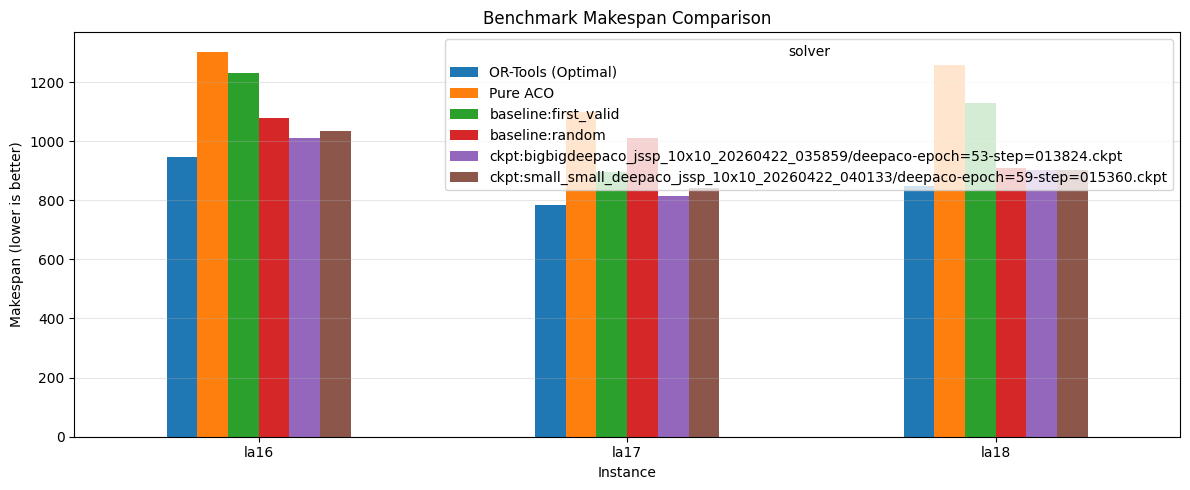

In [52]:
# ===============================
# Plot 1: Makespan Comparison
# ===============================

fig, ax = plt.subplots(figsize=(12, 5))

pivot = df.pivot_table(index='instance', columns='solver', values='makespan', aggfunc='mean')
pivot.plot(kind='bar', ax=ax)

ax.set_title('Benchmark Makespan Comparison')
ax.set_ylabel('Makespan (lower is better)')
ax.set_xlabel('Instance')
ax.grid(axis='y', alpha=0.3)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


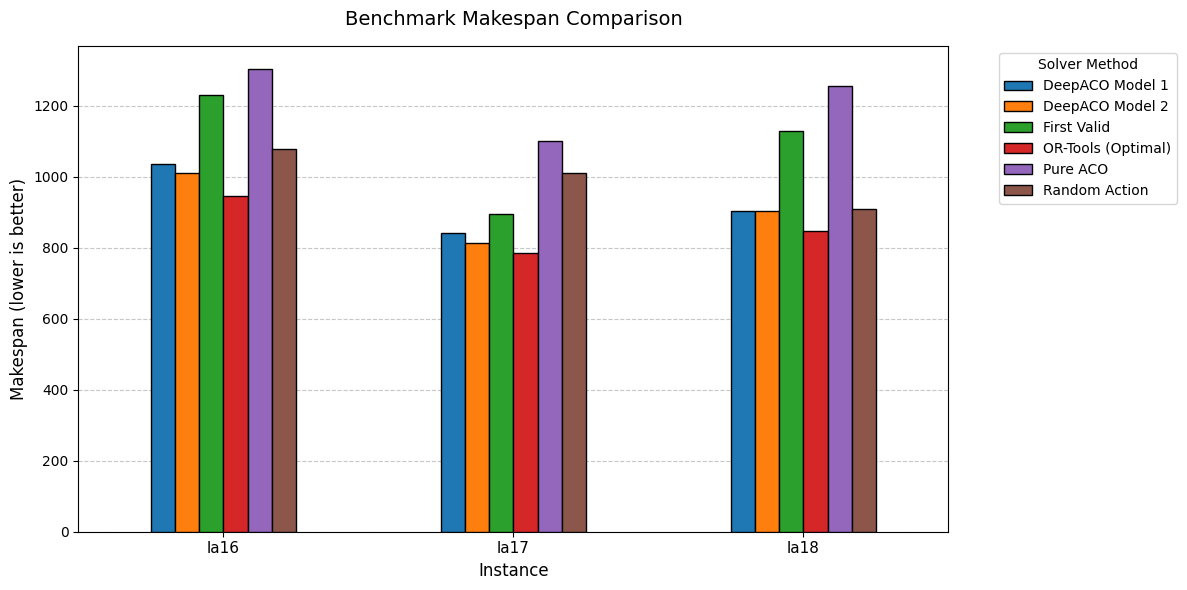

In [53]:
# ===============================
# Plot 1: Makespan Comparison
# ===============================
import matplotlib.pyplot as plt

# --- CUSTOMIZATION DICTIONARIES ---
# Map original instance names to custom X-axis labels
# Example: {'ft06': 'Fisher & Thompson 6x6'}
CUSTOM_X_LABELS = {
    'abz5': 'ABZ-5 (10x10)',
    # 'orb02': 'ORB-02 (10x10)',
}

# Map original solver names to custom Legend labels
# Example: {'baseline:random': 'Random Agent'}
CUSTOM_LEGEND_LABELS = {
    'OR-Tools (Exact Optimum)': 'OR-Tools (Optimum)',
    'Classic ACO (Standalone)': 'Classic ACO',
    'baseline:first_valid': 'First Valid',
    'baseline:random': 'Random Action',
    # Map your specific model path string to a cleaner name here:
    'ckpt:small_small_deepaco_jssp_10x10_20260422_040133/deepaco-epoch=59-step=015360.ckpt': 'DeepACO Model 1',
    'ckpt:bigbigdeepaco_jssp_10x10_20260422_035859/deepaco-epoch=53-step=013824.ckpt': 'DeepACO Model 2',

}
# ----------------------------------

# Create a copy so we don't permanently alter the original dataframe
plot_df = df.copy()

# Apply the custom labels safely
if CUSTOM_X_LABELS:
    plot_df['instance'] = plot_df['instance'].replace(CUSTOM_X_LABELS)
if CUSTOM_LEGEND_LABELS:
    plot_df['solver'] = plot_df['solver'].replace(CUSTOM_LEGEND_LABELS)

fig, ax = plt.subplots(figsize=(12, 6))

# Create pivot table with the customized dataframe
pivot = plot_df.pivot_table(index='instance', columns='solver', values='makespan', aggfunc='mean')

# Plot the bars
pivot.plot(kind='bar', ax=ax, edgecolor='black', zorder=3)

# Styling
ax.set_title('Benchmark Makespan Comparison', fontsize=14, pad=15)
ax.set_ylabel('Makespan (lower is better)', fontsize=12)
ax.set_xlabel('Instance', fontsize=12)
ax.grid(axis='y', linestyle='--', alpha=0.7, zorder=0)

plt.xticks(rotation=0, fontsize=11)

# Move the legend outside the plot so it doesn't cover the bars
plt.legend(title='Solver Method', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

In [ ]:
# ===============================
# Plot 2: Percent Gap to Optimum (if available)
# ===============================

df_gap = df.dropna(subset=['optimum']).copy()
if not df_gap.empty:
    df_gap['gap_pct'] = (df_gap['makespan'] - df_gap['optimum']) / df_gap['optimum'] * 100.0

    fig, ax = plt.subplots(figsize=(12, 5))
    gap_pivot = df_gap.pivot_table(index='instance', columns='solver', values='gap_pct', aggfunc='mean')
    gap_pivot.plot(kind='bar', ax=ax)

    ax.axhline(0.0, color='black', linewidth=1)
    ax.set_title('Percent Gap to Benchmark Optimum')
    ax.set_ylabel('Gap (%) lower is better')
    ax.set_xlabel('Instance')
    ax.grid(axis='y', alpha=0.3)
    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.show()
else:
    print('No optimum metadata available for selected instances.')


## Notes

- Set `MODEL_PATHS` directly to the `.pt` or `.ckpt` files you want to compare.
- Set `BENCHMARK_KEYWORDS` to exact names like `ft06` or prefixes/groups like `ft`, `ta`, `la`, `abz`, or `all`.
- If `MODEL_PATHS` is empty, the notebook falls back to auto-discovered local and Drive artifacts.
- If `TRUST_CHECKPOINTS=True`, the notebook will use a more permissive fallback loader for your own Lightning checkpoints.
- Set `RUN_CLASSIC_ACO=True` to compare against a plain non-neural ACO baseline.
- This notebook currently evaluates one instance at a time (`batch_size=1`).
- If a benchmark is skipped, it usually means model architecture dimensions do not match that instance.
  Example: a model trained for `6x6` will not load for `10x10`/`15x15` without retraining.
- `.ckpt` and `.pt` are both supported. `.ckpt` loads `state_dict` automatically.
